In [10]:
import pandas as pd

In [11]:
df = pd.read_csv(r'C:\Users\SAHITHI KODUMURI\Documents\Fraud-detection-baseline\data\creditcard.csv')

In [12]:
df.shape

(284807, 31)

In [13]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [14]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Initial Observations of the dataset
1) The data set has 2,84,315 rows, 31 columns and no missing values.
2) Severe class imbalance - fraud is only ~0.17% of total transactions(492 out of 284315).
3) Accuracy will be a misleading metric in this case. So, precision, recall and F1 matter more in this case.

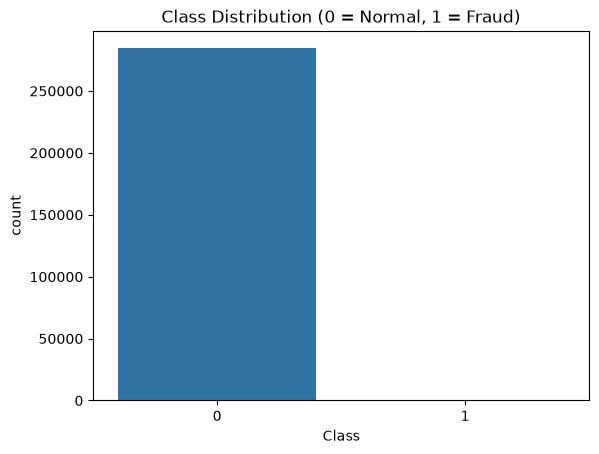

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class distribution plot
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.show()

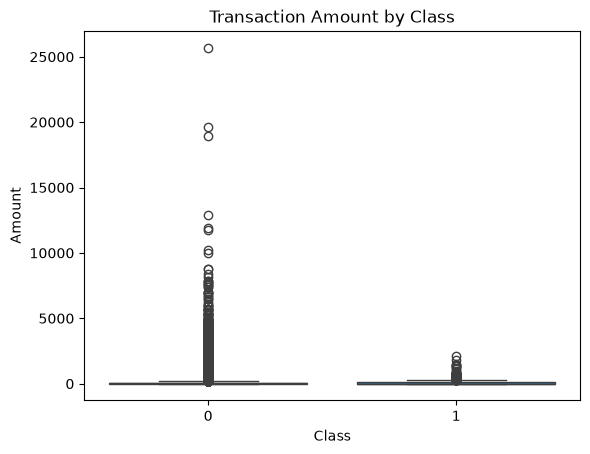

In [17]:
# 2. Amount distribution by class
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.show()

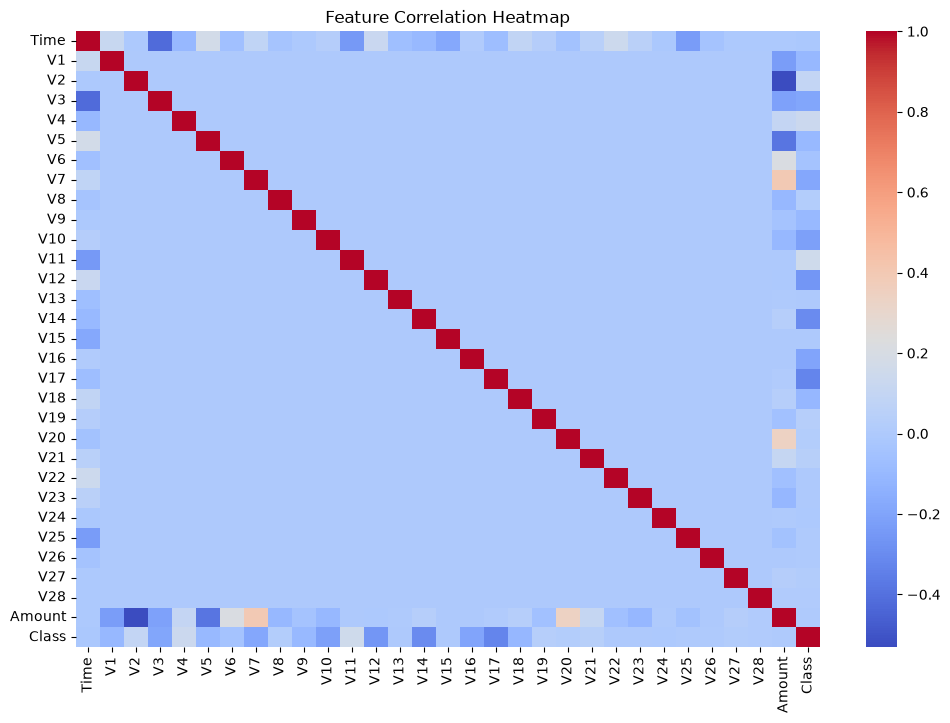

In [18]:
# 3. Correlation heatmap (just a quick look)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.69      0.75        98

    accuracy                           1.00     56962
   macro avg       0.90      0.85      0.87     56962
weighted avg       1.00      1.00      1.00     56962



C:\Users\SAHITHI KODUMURI\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Baseline Model Results (Logistic Regression)
- Precision (fraud): 0.81, Recall (fraud): 0.69, F1: 0.75
- Despite 100% overall accuracy, the model misses ~31% of actual fraud cases, which confirms why accuracy is a poor metric for imbalanced data
- Model didn't fully converge 
- next step: scale features and/or try a tree-based model (Random Forest).